# 🐶 Dog Detection with Bounding Box & Confidence Score
### Using EUPE ViT-B Backbone + COCO Dataset — Kaggle Notebook

**What this notebook does:**
- Downloads and sets up the EUPE ViT-B pretrained backbone (86M params)
- Downloads COCO 2017 dataset and filters dog-only annotations (class 17)
- Builds a Detection Head: per-patch confidence score + bounding box regression
- Trains in two phases: frozen backbone → then partial backbone unfreeze
- Runs inference: draws bounding box + confidence score on any input image

**Architecture at a glance:**
```
Image → EUPE ViT-B (frozen/partial) → patch_tokens [B, 256, 768]
                                              ↓
                                     Detection Head
                                      ├── conf branch → sigmoid → confidence (0–1)
                                      └── bbox branch → sigmoid → (cx,cy,w,h)
                                              ↓
                                   NMS post-processing
                                              ↓
                              [x1,y1,x2,y2] + confidence score
```

**Kaggle resources:**
- GPU: T4 x1 (16 GB VRAM)
- RAM: 29 GB
- Disk: ~30 GB free needed

---
> ⚠️ **Before running:** Settings → Accelerator → **GPU T4 x1**

## STEP 1 — Verify GPU & Environment

In [3]:
import torch, sys, shutil

print('Python  :', sys.version)
print('PyTorch :', torch.__version__)
print('CUDA    :', torch.version.cuda)
print('GPU     :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NOT FOUND')
print('VRAM    :', round(torch.cuda.get_device_properties(0).total_memory/1e9,1), 'GB')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device  :', DEVICE)

total, used, free = shutil.disk_usage('/')
print(f'Disk free: {free//(2**30)} GB')

Python  : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch : 2.10.0+cu128
CUDA    : 12.8
GPU     : Tesla T4
VRAM    : 15.6 GB
Device  : cuda
Disk free: 1220 GB


## STEP 2 — Install Required Packages

- `pycocotools` — official COCO annotation parser
- `huggingface_hub` — to download the EUPE ViT-B checkpoint
- `torchvision` — already on Kaggle; used for NMS and transforms
- `timm` — needed by EUPE's ViT-B implementation

In [4]:
!pip install -q pycocotools huggingface_hub timm
print('Done.')

Done.


## STEP 3 — Clone EUPE Repository

We need the repo for the ViT-B model architecture code.
📌 https://github.com/facebookresearch/EUPE

In [5]:
import os

EUPE_DIR = '/kaggle/working/EUPE'

if not os.path.exists(EUPE_DIR):
    !git clone https://github.com/facebookresearch/EUPE {EUPE_DIR}
    print('Cloned.')
else:
    print('Already exists, skipping.')

for f in ['hubconf.py', 'eupe']:
    status = '✓' if os.path.exists(f'{EUPE_DIR}/{f}') else '✗ MISSING'
    print(f'  {status}  {f}')

Cloning into '/kaggle/working/EUPE'...
remote: Enumerating objects: 124, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (111/111), done.61% (68/111)
remote: Total 124 (delta 10), reused 124 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (124/124), 856.19 KiB | 7.58 MiB/s, done.
Resolving deltas: 100% (10/10), done.
Cloned.
  ✓  hubconf.py
  ✓  eupe


## STEP 4 — Download EUPE ViT-B Pretrained Checkpoint

ViT-B is the larger model:
- **Embed dim: 768** (vs 192 for ViT-T)
- **12 transformer blocks** (vs 4)
- **~86M parameters** — much richer features, better for detection

📌 Checkpoint: https://huggingface.co/facebook/EUPE-ViT-B

In [6]:
from huggingface_hub import hf_hub_download, list_repo_files

CHECKPOINT_PATH = '/kaggle/working/eupe_vitb16.pt'

if not os.path.exists(CHECKPOINT_PATH):
    print('Listing files in facebook/EUPE-ViT-B ...')
    files = list(list_repo_files('facebook/EUPE-ViT-B'))
    for f in files:
        print(' ', f)

    pt_files = [f for f in files if f.endswith('.pt') or f.endswith('.pth')]
    assert pt_files, 'No checkpoint found — check the repo manually.'

    ckpt_filename = pt_files[0]
    print(f'Downloading: {ckpt_filename}')
    local_path = hf_hub_download(
        repo_id='facebook/EUPE-ViT-B',
        filename=ckpt_filename,
        local_dir='/kaggle/working'
    )
    if local_path != CHECKPOINT_PATH:
        os.rename(local_path, CHECKPOINT_PATH)
    print(f'Saved to: {CHECKPOINT_PATH}')
else:
    print('Checkpoint already exists.')

print(f'Size: {os.path.getsize(CHECKPOINT_PATH)/1e6:.1f} MB')

Listing files in facebook/EUPE-ViT-B ...
  .gitattributes
  EUPE-ViT-B.pt
  README.md
Downloading: EUPE-ViT-B.pt


EUPE-ViT-B.pt:   0%|          | 0.00/400M [00:00<?, ?B/s]

Saved to: /kaggle/working/eupe_vitb16.pt
Size: 399.5 MB


## STEP 5 — Load EUPE ViT-B Backbone

Key output shapes for ViT-B:
- `cls_token`    : `[B, 768]`   — whole-image summary (not used for detection)
- `patch_tokens` : `[B, 256, 768]` — **one 768-dim vector per 16×16 patch** ← detection uses this

We freeze the entire backbone first. It will be partially unfrozen in Phase 2 training.

In [10]:
import torch

EMBED_DIM  = 768   # ViT-B hidden dimension
IMG_SIZE   = 256
PATCH_SIZE = 16
PATCH_GRID = IMG_SIZE // PATCH_SIZE  # 16 × 16 = 256 patches

print('Loading EUPE ViT-B backbone...')
backbone = torch.hub.load(
    EUPE_DIR,
    'eupe_vitb16',
    source='local',
    weights=CHECKPOINT_PATH
)
backbone.eval()
backbone = backbone.to(DEVICE)

# Freeze all backbone parameters
for p in backbone.parameters():
    p.requires_grad = False

total  = sum(p.numel() for p in backbone.parameters())
print(f'Backbone loaded  : {total/1e6:.1f}M parameters (all frozen)')

# Smoke test
with torch.inference_mode():
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out          = backbone.forward_features(dummy)
    cls_token    = out['x_norm_clstoken']    # [1, 768]
    patch_tokens = out['x_norm_patchtokens'] # [1, 256, 768]
    print(f'cls_token shape   : {cls_token.shape}')     # [1, 768]
    print(f'patch_tokens shape: {patch_tokens.shape}')  # [1, 256, 768]
print('Smoke test passed ✓')

Loading EUPE ViT-B backbone...
missing keys when loading vitb: []
unexpected keys when loading vitb: ['projectors.heads.dinov3radio_vitg16.cls.layers.0.weight', 'projectors.heads.dinov3radio_vitg16.cls.layers.1.weight', 'projectors.heads.dinov3radio_vitg16.cls.layers.1.bias', 'projectors.heads.dinov3radio_vitg16.cls.layers.3.weight', 'projectors.heads.dinov3radio_vitg16.patch.layers.0.weight', 'projectors.heads.dinov3radio_vitg16.patch.layers.1.weight', 'projectors.heads.dinov3radio_vitg16.patch.layers.1.bias', 'projectors.heads.dinov3radio_vitg16.patch.layers.3.weight']
Backbone loaded  : 85.7M parameters (all frozen)
cls_token shape   : torch.Size([1, 768])
patch_tokens shape: torch.Size([1, 256, 768])
Smoke test passed ✓


## STEP 6 — Download COCO 2017 Dataset

📌 Source: https://cocodataset.org  
We download:
- `train2017.zip` — 118K training images (~18 GB)
- `val2017.zip`   — 5K validation images (~1 GB)
- `annotations_trainval2017.zip` — JSON annotations (~241 MB)

**Faster option:** Add the Kaggle COCO dataset directly via the right panel.
- Search: `coco-2017-dataset` by `awsaf49`
- Path: `/kaggle/input/coco-2017-dataset/`

> 💡 The cell below checks for the Kaggle dataset first. If found, it skips the download entirely.

In [17]:
from pathlib import Path
import os

# ── Kaggle uploaded COCO dataset path ─────────────────────────
COCO_ROOT = Path('/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017')  # adjust if needed
TRAIN_IMG_DIR  = COCO_ROOT / 'train2017'
VAL_IMG_DIR    = COCO_ROOT / 'val2017'
TRAIN_ANN_FILE = COCO_ROOT / 'annotations/instances_train2017.json'
VAL_ANN_FILE   = COCO_ROOT / 'annotations/instances_val2017.json'

print(f'Train images : {TRAIN_IMG_DIR}')
print(f'Val images   : {VAL_IMG_DIR}')
print(f'Train ann    : {TRAIN_ANN_FILE}')
print(f'Val ann      : {VAL_ANN_FILE}')

Train images : /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017
Val images   : /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017
Train ann    : /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_train2017.json
Val ann      : /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_val2017.json


In [13]:
TRAIN_IMG_DIR  = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017'
VAL_IMG_DIR    = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017'
TRAIN_ANN_FILE = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/captions_train2017.json'
VAL_ANN_FILE   = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/captions_val2017.json'


## STEP 7 — Filter COCO for Dog Images Only

COCO has 80 classes. **Dog = category ID 18** (1-indexed in annotations).  

We:
1. Use `pycocotools` to parse the JSON annotations
2. Extract only images that contain at least one dog bounding box
3. Cap training at **8,000 images** and validation at **1,000** for speed

Each annotation gives us:  
`[x_min, y_min, width, height]` — COCO format, absolute pixel coords

In [18]:
from pycocotools.coco import COCO

DOG_CATEGORY_ID = 18  # COCO category id for 'dog'
MAX_TRAIN       = 8000
MAX_VAL         = 1000

def get_dog_samples(ann_file, img_dir, max_samples):
    coco    = COCO(str(ann_file))
    img_ids = coco.getImgIds(catIds=[DOG_CATEGORY_ID])
    print(f'Total images with dogs: {len(img_ids)}')
    img_ids = img_ids[:max_samples]

    samples = []
    for img_id in img_ids:
        info     = coco.loadImgs(img_id)[0]
        ann_ids  = coco.getAnnIds(imgIds=img_id, catIds=[DOG_CATEGORY_ID], iscrowd=False)
        anns     = coco.loadAnns(ann_ids)

        boxes = []
        for ann in anns:
            x, y, w, h = ann['bbox']
            if w < 10 or h < 10:  # skip tiny boxes
                continue
            boxes.append([x, y, x+w, y+h])

        if not boxes:
            continue

        img_path = str(Path(img_dir) / info['file_name'])
        if not os.path.exists(img_path):
            continue

        samples.append({
            'img_path': img_path,
            'boxes'   : boxes,
            'img_w'   : info['width'],
            'img_h'   : info['height']
        })

    return samples

# ── Load dog images ─────────────────────────────
print('Loading training annotations...')
train_samples = get_dog_samples(TRAIN_ANN_FILE, TRAIN_IMG_DIR, MAX_TRAIN)
print(f'Train dog samples: {len(train_samples)}')

print('Loading validation annotations...')
val_samples = get_dog_samples(VAL_ANN_FILE, VAL_IMG_DIR, MAX_VAL)
print(f'Val dog samples  : {len(val_samples)}')

# Quick peek
s = train_samples[0]
print(f'\nSample image  : {s["img_path"]}')
print(f'Image size    : {s["img_w"]}×{s["img_h"]}')
print(f'Dog boxes     : {s["boxes"]}')

Loading training annotations...
loading annotations into memory...
Done (t=15.18s)
creating index...
index created!
Total images with dogs: 4385
Train dog samples: 4360
Loading validation annotations...
loading annotations into memory...
Done (t=0.57s)
creating index...
index created!
Total images with dogs: 177
Val dog samples  : 175

Sample image  : /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000098304.jpg
Image size    : 640×424
Dog boxes     : [[263.87, 216.88, 285.0, 232.04999999999998]]


## STEP 8 — Build COCO Dog Detection Dataset

**Per-patch supervision strategy:**

The image is divided into a 16×16 grid of patches (each patch = 16×16 pixels in a 256×256 image).  
For each patch we ask: *does a dog bounding box overlap this patch?*

```
IoU(patch_cell, gt_box) > 0.4  →  positive patch  (label=1, assign box coords)
IoU(patch_cell, gt_box) < 0.1  →  negative patch  (label=0)
Between 0.1 and 0.4            →  ignored (not used in loss)
```

Each sample returns:
- `img_tensor`  : `[3, 256, 256]`
- `conf_targets`: `[16, 16]`       — 1 where dog exists, 0 elsewhere
- `bbox_targets`: `[16, 16, 4]`    — (cx, cy, w, h) normalised 0–1, valid only on positive patches

In [38]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from PIL import Image

def make_transform(augment=False):
    ops = [v2.ToImage(), v2.Resize((IMG_SIZE, IMG_SIZE), antialias=True)]
    if augment:
        ops += [
            v2.RandomHorizontalFlip(p=0.5),
            v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        ]
    ops += [
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ]
    return v2.Compose(ops)

def compute_iou_patch(patch_box, gt_box):
    px1, py1, px2, py2 = patch_box
    gx1, gy1, gx2, gy2 = gt_box
    ix1 = max(px1, gx1); iy1 = max(py1, gy1)
    ix2 = min(px2, gx2); iy2 = min(py2, gy2)
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    union = (px2-px1)*(py2-py1) + (gx2-gx1)*(gy2-gy1) - inter
    return inter / (union + 1e-6)

class COCODogDataset(Dataset):
    """
    FIX: center-inside assignment strategy.
    A patch is positive if its CENTER falls inside any GT box.
    This gives proportional coverage (big dog=many positives, small dog=at least 1),
    fixing the 1:1000 imbalance. IoU kept as secondary fallback.
    NEG_THRESH tightened to 0.02 so border patches stay in ignore zone.
    """
    POS_THRESH = 0.15
    NEG_THRESH = 0.02

    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform or make_transform()
        self.cell_size = 1.0 / PATCH_GRID

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s     = self.samples[idx]
        img_w = s['img_w'];  img_h = s['img_h']

        img   = Image.open(s['img_path']).convert('RGB')
        img_t = self.transform(img)

        norm_boxes = []
        for x1, y1, x2, y2 in s['boxes']:
            norm_boxes.append([
                max(0.0, min(1.0, x1/img_w)), max(0.0, min(1.0, y1/img_h)),
                max(0.0, min(1.0, x2/img_w)), max(0.0, min(1.0, y2/img_h))
            ])

        conf_targets = torch.full((PATCH_GRID, PATCH_GRID), -1.0)
        bbox_targets = torch.zeros(PATCH_GRID, PATCH_GRID, 4)

        for i in range(PATCH_GRID):
            for j in range(PATCH_GRID):
                px1 = j * self.cell_size;  px2 = px1 + self.cell_size
                py1 = i * self.cell_size;  py2 = py1 + self.cell_size
                pcx = (px1 + px2) / 2;    pcy = (py1 + py2) / 2

                best_iou     = 0.0
                best_box     = None
                center_match = False

                for gb in norm_boxes:
                    gx1, gy1, gx2, gy2 = gb
                    inside = (gx1 <= pcx <= gx2) and (gy1 <= pcy <= gy2)
                    iou    = compute_iou_patch([px1,py1,px2,py2], gb)
                    if inside or iou > best_iou:
                        best_iou     = iou
                        best_box     = gb
                        center_match = inside

                if best_box is not None:
                    gx1, gy1, gx2, gy2 = best_box
                    if center_match or best_iou >= self.POS_THRESH:
                        conf_targets[i, j] = 1.0
                        bbox_targets[i, j] = torch.tensor([
                            (gx1+gx2)/2, (gy1+gy2)/2, gx2-gx1, gy2-gy1
                        ])
                    elif best_iou < self.NEG_THRESH:
                        conf_targets[i, j] = 0.0
                else:
                    conf_targets[i, j] = 0.0

        return img_t, conf_targets, bbox_targets


BATCH_SIZE = 16

train_dataset = COCODogDataset(train_samples, transform=make_transform(augment=True))
val_dataset   = COCODogDataset(val_samples)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=4, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4, pin_memory=True)

print(f'Train: {len(train_dataset)} samples  |  {len(train_loader)} batches')
print(f'Val  : {len(val_dataset)} samples  |  {len(val_loader)} batches')

imgs, conf, bbox = next(iter(train_loader))
pos = (conf == 1).sum().item()
neg = (conf == 0).sum().item()
ign = (conf == -1).sum().item()
print(f'\nBatch shapes:')
print(f'  imgs         : {imgs.shape}')
print(f'  conf_targets : {conf.shape}')
print(f'  bbox_targets : {bbox.shape}')
print(f'  positive patches : {pos}')
print(f'  negative patches : {neg}')
print(f'  ignored  patches : {ign}')
print(f'  neg/pos ratio    : {neg/max(pos,1):.1f}x  (target: <50x)')
assert pos > 0, 'FATAL: no positive patches found!'
print('Positive patches confirmed.')


Train: 4360 samples  |  273 batches
Val  : 175 samples  |  11 batches

Batch shapes:
  imgs         : torch.Size([16, 3, 256, 256])
  conf_targets : torch.Size([16, 16, 16])
  bbox_targets : torch.Size([16, 16, 16, 4])
  positive patches : 685
  negative patches : 3394
  ignored  patches : 17
  neg/pos ratio    : 5.0x  (target: <50x)
Positive patches confirmed.


## STEP 9 — Build the Detection Head

The Detection Head takes `patch_tokens [B, 256, 768]` from the ViT-B backbone.

```
patch_tokens [B, 256, 768]
        ↓
   LayerNorm(768)
        ↓
   Linear(768 → 512) + GELU
        ↓
   Dropout(0.1)
        ↓
   ├── conf_branch: Linear(512 → 1) → sigmoid → [B, 16, 16]
   └── bbox_branch: Linear(512 → 4) → sigmoid → [B, 16, 16, 4]  (cx,cy,w,h)
```

**Why sigmoid on bbox?** Forces output to [0,1] — consistent with normalised coords.

In [64]:
class TransformerDetectionHead(nn.Module):
    """
    Transformer Decoder detection head on top of EUPE ViT-B patch tokens.

    Key upgrade over simple Linear head:
    - Self-attention lets patches communicate across the full 16x16 grid
    - Dog patches reinforce each other; isolated noise patches get suppressed
    - Result: higher confidence on real dogs, fewer false positives

    Input : patch_tokens  [B, 256, 768]
    Output: conf_pred     [B, 16, 16]
            bbox_pred     [B, 16, 16, 4]  (cx, cy, w, h) normalised
    """
    def __init__(self, embed_dim=768, hidden=256, nhead=4, num_layers=4, grid=PATCH_GRID):
        super().__init__()
        self.grid = grid

        # Project backbone dim (768) down to transformer working dim (256)
        self.input_proj = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
        )

        # Learnable positional embeddings for the 256 patch positions
        self.pos_embed = nn.Parameter(torch.zeros(1, grid*grid, hidden))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        # Transformer encoder (self-attention across all patches)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=nhead,
            dim_feedforward=hidden * 4,
            dropout=0.1,
            activation='gelu',
            batch_first=True,
            norm_first=True,   # pre-norm: more stable training
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Output heads
        self.conf_head = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, 64),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1),
        )
        self.bbox_head = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, 64),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(64, 4),
        )

        self._init_weights()

    def _init_weights(self):
        # Initialise conf bias so initial sigmoid output ~ 0.01
        # Prevents the model from predicting everything as dog at epoch 0
        nn.init.constant_(self.conf_head[-1].bias, -4.6)  # sigmoid(-4.6) ~ 0.01
        nn.init.xavier_uniform_(self.conf_head[-1].weight)
        nn.init.xavier_uniform_(self.bbox_head[-1].weight)

    def forward(self, patch_tokens):
        B = patch_tokens.shape[0]

        # Project and add positional embeddings
        x = self.input_proj(patch_tokens)           # [B, 256, 256]
        x = x + self.pos_embed                      # [B, 256, 256]

        # Self-attention across all patches
        x = self.transformer(x)                     # [B, 256, 256]

        # Predict confidence and boxes per patch
        conf = torch.sigmoid(self.conf_head(x))     # [B, 256, 1]
        conf = conf.squeeze(-1).reshape(B, self.grid, self.grid)   # [B, 16, 16]

        bbox = torch.sigmoid(self.bbox_head(x))     # [B, 256, 4]
        bbox = bbox.reshape(B, self.grid, self.grid, 4)            # [B, 16, 16, 4]

        return conf, bbox


class EUPEDetector(nn.Module):
    """Full pipeline: EUPE ViT-B backbone + Transformer Detection Head."""
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.det_head = TransformerDetectionHead(
            embed_dim=EMBED_DIM,
            hidden=256,
            nhead=4,
            num_layers=4,
            grid=PATCH_GRID
        )

    def forward(self, x):
        with torch.set_grad_enabled(any(p.requires_grad for p in self.backbone.parameters())):
            out          = self.backbone.forward_features(x)
            patch_tokens = out['x_norm_patchtokens']   # [B, 256, 768]
        conf, bbox = self.det_head(patch_tokens)
        return conf, bbox

    def unfreeze_last_n_blocks(self, n=4):
        """Unfreeze the last n transformer blocks for Phase 2 fine-tuning."""
        blocks = list(self.backbone.blocks)
        for block in blocks[-n:]:
            for p in block.parameters():
                p.requires_grad = True
        for p in self.backbone.norm.parameters():
            p.requires_grad = True
        unfrozen = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total    = sum(p.numel() for p in self.parameters())
        print(f'Unfrozen last {n} blocks + norm')
        print(f'Trainable: {unfrozen/1e6:.1f}M / {total/1e6:.1f}M params')


# ── Instantiate ──────────────────────────────────────────────────────────
model = EUPEDetector(backbone).to(DEVICE)

head_params = sum(p.numel() for p in model.det_head.parameters())
print(f'Transformer detection head params: {head_params/1e6:.2f}M')
print(f'  (vs 0.40M for old linear head -- {head_params/400000:.1f}x more expressive)')

# Smoke test
with torch.inference_mode():
    dummy = torch.randn(2, 3, 256, 256).to(DEVICE)
    c, b  = model(dummy)
    print(f'conf_pred shape : {c.shape}')   # [2, 16, 16]
    print(f'bbox_pred shape : {b.shape}')   # [2, 16, 16, 4]
    print(f'conf range      : [{c.min():.3f}, {c.max():.3f}]  (should be ~0.01 at init)')
print('Transformer head smoke test passed.')


Transformer detection head params: 3.46M
  (vs 0.40M for old linear head -- 8.6x more expressive)
conf_pred shape : torch.Size([2, 16, 16])
bbox_pred shape : torch.Size([2, 16, 16, 4])
conf range      : [0.006, 0.014]  (should be ~0.01 at init)
Transformer head smoke test passed.


/tmp/ipykernel_55/3542267463.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


## STEP 10 — Loss Functions

Two losses combined:

**1. Confidence Loss — Focal Loss**  
Standard BCE would be crushed by class imbalance (most patches are negative).  
Focal Loss down-weights easy negatives so the model focuses on hard examples.

**2. Box Regression Loss — CIoU Loss**  
Applied only on positive patches. CIoU jointly optimises:
- Overlap area
- Centre point distance
- Aspect ratio similarity

```
Total Loss = Focal Loss (all patches) + λ_box × CIoU Loss (positive patches only)
λ_box = 5.0
```

In [65]:
def focal_loss(pred_conf, targets, alpha=0.25, gamma=2.0):
    """
    Focal Loss -- alpha_t correctly applied per class:
    alpha for positives, (1-alpha) for negatives.
    """
    mask    = targets != -1
    pred    = pred_conf[mask]
    tgt     = targets[mask]
    bce     = torch.nn.functional.binary_cross_entropy(pred, tgt, reduction='none')
    pt      = torch.where(tgt == 1, pred, 1 - pred)
    alpha_t = torch.where(tgt == 1,
                          torch.full_like(pred, alpha),
                          torch.full_like(pred, 1.0 - alpha))
    weight  = alpha_t * (1 - pt) ** gamma
    return (weight * bce).mean()


def ciou_loss(pred_boxes, target_boxes):
    """CIoU loss on positive patches only. Inputs: (cx,cy,w,h) normalised."""
    def to_xyxy(b):
        return torch.stack([
            b[...,0]-b[...,2]/2, b[...,1]-b[...,3]/2,
            b[...,0]+b[...,2]/2, b[...,1]+b[...,3]/2
        ], dim=-1)
    p = to_xyxy(pred_boxes);  g = to_xyxy(target_boxes)
    ix1 = torch.max(p[...,0],g[...,0]); iy1 = torch.max(p[...,1],g[...,1])
    ix2 = torch.min(p[...,2],g[...,2]); iy2 = torch.min(p[...,3],g[...,3])
    inter = (ix2-ix1).clamp(0)*(iy2-iy1).clamp(0)
    pw=(p[...,2]-p[...,0]).clamp(0); ph=(p[...,3]-p[...,1]).clamp(0)
    gw=(g[...,2]-g[...,0]).clamp(0); gh=(g[...,3]-g[...,1]).clamp(0)
    union = pw*ph + gw*gh - inter + 1e-6
    iou   = inter / union
    cw  = torch.max(p[...,2],g[...,2]) - torch.min(p[...,0],g[...,0])
    ch  = torch.max(p[...,3],g[...,3]) - torch.min(p[...,1],g[...,1])
    c2  = cw**2 + ch**2 + 1e-6
    rho2= ((p[...,0]+p[...,2])/2-(g[...,0]+g[...,2])/2)**2 + \
          ((p[...,1]+p[...,3])/2-(g[...,1]+g[...,3])/2)**2
    v   = (4/(torch.pi**2))*(torch.atan(gw/(gh+1e-6))-torch.atan(pw/(ph+1e-6)))**2
    with torch.no_grad():
        alpha_v = v / (1 - iou + v + 1e-6)
    return (1 - (iou - rho2/c2 - alpha_v*v)).mean()


def detection_loss(conf_pred, bbox_pred, conf_targets, bbox_targets, lambda_box=2.0):
    """
    Combined Focal + CIoU loss.
    FIX: lambda_box reduced 5.0 -> 2.0 because with more positive patches
    the box loss is no longer negligible and would overpower conf learning.
    """
    loss_conf = focal_loss(conf_pred, conf_targets)
    pos_mask  = conf_targets == 1
    loss_box  = torch.tensor(0.0, device=conf_pred.device)
    if pos_mask.sum() > 0:
        loss_box = ciou_loss(bbox_pred[pos_mask], bbox_targets[pos_mask])
    total = loss_conf + lambda_box * loss_box
    return total, loss_conf.item(), loss_box.item()


print('Loss functions defined.')
dummy_conf  = torch.rand(2, 16, 16)
dummy_tgt_c = torch.randint(-1, 2, (2, 16, 16)).float()
dummy_bbox  = torch.rand(2, 16, 16, 4)
dummy_tgt_b = torch.rand(2, 16, 16, 4)
loss, lc, lb = detection_loss(dummy_conf, dummy_bbox, dummy_tgt_c, dummy_tgt_b)
print(f'Sanity check - total={loss:.4f}  conf={lc:.4f}  box={lb:.4f}')


Loss functions defined.
Sanity check - total=2.6204  conf=0.2948  box=1.1628


## STEP 11 — Phase 1 Training: Frozen Backbone, Train Detection Head Only

- Backbone: **fully frozen**
- Only `det_head` parameters update
- Epochs: **10**
- Optimizer: AdamW, LR=1e-3, weight decay=1e-4
- Scheduler: CosineAnnealingLR

**Metric tracked:** Precision@0.5 — fraction of predicted boxes with IoU > 0.5 with a gt box

In [69]:
from tqdm.notebook import tqdm
from torch.optim.lr_scheduler import OneCycleLR

PHASE1_EPOCHS = 15   # more epochs -- transformer head needs longer to converge
PHASE1_LR     = 1e-4

optimizer_p1 = torch.optim.AdamW(
    model.det_head.parameters(), lr=PHASE1_LR, weight_decay=1e-4)

# OneCycleLR: linear warmup for 3 epochs then cosine decay
# Warmup is important for transformer -- avoids instability at epoch 1
scheduler_p1 = OneCycleLR(
    optimizer_p1,
    max_lr=PHASE1_LR,
    steps_per_epoch=len(train_loader),
    epochs=PHASE1_EPOCHS,
    pct_start=0.2,        # 20% of training = warmup
    anneal_strategy='cos',
)

def evaluate(model, loader, conf_thresh=0.3):
    """Patch-level precision / recall / F1."""
    model.eval()
    total_loss, tp, fp, fn, n_batch = 0.0, 0, 0, 0, 0
    with torch.inference_mode():
        for imgs, conf_t, bbox_t in loader:
            imgs, conf_t, bbox_t = imgs.to(DEVICE), conf_t.to(DEVICE), bbox_t.to(DEVICE)
            conf_p, bbox_p       = model(imgs)
            loss, _, _           = detection_loss(conf_p, bbox_p, conf_t, bbox_t)
            total_loss          += loss.item()
            pos_mask = conf_t == 1;  neg_mask = conf_t == 0
            tp += ((conf_p >= conf_thresh) & pos_mask).sum().item()
            fp += ((conf_p >= conf_thresh) & neg_mask).sum().item()
            fn += ((conf_p <  conf_thresh) & pos_mask).sum().item()
            n_batch += 1
    precision = tp / (tp + fp + 1e-6)
    recall    = tp / (tp + fn + 1e-6)
    f1        = 2*precision*recall / (precision+recall+1e-6)
    return total_loss/n_batch, precision, recall, f1


print('=== PHASE 1: Training Transformer Head (backbone frozen) ===')
best_f1        = 0.0
patience_count = 0
PATIENCE       = 8

for epoch in range(1, PHASE1_EPOCHS + 1):
    model.train()
    epoch_loss, epoch_lc, epoch_lb, n = 0.0, 0.0, 0.0, 0

    for imgs, conf_t, bbox_t in tqdm(train_loader, desc=f'P1 Epoch {epoch}/{PHASE1_EPOCHS}', leave=False):
        imgs, conf_t, bbox_t = imgs.to(DEVICE), conf_t.to(DEVICE), bbox_t.to(DEVICE)
        conf_p, bbox_p       = model(imgs)
        loss, lc, lb         = detection_loss(conf_p, bbox_p, conf_t, bbox_t)
        optimizer_p1.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.det_head.parameters(), max_norm=1.0)
        optimizer_p1.step()
        scheduler_p1.step()  # OneCycleLR steps every batch
        epoch_loss += loss.item(); epoch_lc += lc; epoch_lb += lb; n += 1

    val_loss, prec, rec, f1 = evaluate(model, val_loader)
    improved = f1 > best_f1
    if improved:
        best_f1 = f1
        patience_count = 0
        torch.save(model.det_head.state_dict(), '/kaggle/working/best_det_head_p1.pt')
    else:
        patience_count += 1

    print(f'Epoch {epoch:02d} | '
          f'train_loss={epoch_loss/n:.4f}  conf={epoch_lc/n:.4f}  box={epoch_lb/n:.4f} | '
          f'val_loss={val_loss:.4f}  P={prec:.3f}  R={rec:.3f}  F1={f1:.3f} '
          f'{"★" if improved else f"(patience {patience_count}/{PATIENCE})"}')

    if patience_count >= PATIENCE:
        print(f'Early stopping at epoch {epoch}.')
        break

# Load best before Phase 2
model.det_head.load_state_dict(
    torch.load('/kaggle/working/best_det_head_p1.pt', map_location=DEVICE))
print(f'Loaded best Phase-1 weights.')
print(f'\nPhase 1 complete. Best F1: {best_f1:.3f}')


=== PHASE 1: Training Transformer Head (backbone frozen) ===


P1 Epoch 1/15:   0%|          | 0/273 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.4357  conf=0.0214  box=0.2071 | val_loss=0.5333  P=0.734  R=0.903  F1=0.810 ★


P1 Epoch 2/15:   0%|          | 0/273 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.4376  conf=0.0215  box=0.2081 | val_loss=0.5639  P=0.733  R=0.896  F1=0.806 (patience 1/8)


...

Epoch 13 | train_loss=0.3643  conf=0.0187  box=0.1728 | val_loss=0.5334  P=0.747  R=0.897  F1=0.815 (patience 1/8)


P1 Epoch 14/15:   0%|          | 0/273 [00:00<?, ?it/s]

Epoch 14 | train_loss=0.3630  conf=0.0186  box=0.1722 | val_loss=0.5337  P=0.749  R=0.896  F1=0.816 ★


P1 Epoch 15/15:   0%|          | 0/273 [00:00<?, ?it/s]

Epoch 15 | train_loss=0.3610  conf=0.0186  box=0.1712 | val_loss=0.5328  P=0.750  R=0.895  F1=0.816 (patience 1/8)
Loaded best Phase-1 weights.

Phase 1 complete. Best F1: 0.816


## STEP 12 — Phase 2 Training: Unfreeze Last 4 Backbone Blocks

Now that the detection head has learned what to look for, we let the backbone  
**slowly adapt** its representations to dog-in-scene features.

- Unfreeze: **last 4 transformer blocks** + final LayerNorm of ViT-B
- Backbone LR: **1e-5** (10× smaller — avoid catastrophic forgetting)
- Head LR: **1e-4**
- Epochs: **5**

> Why only last 4 blocks? Early blocks learn low-level edges/textures (universal, don't need updating).  
> Later blocks learn semantic concepts — those need to shift toward 'dog in complex scene'.

In [70]:
PHASE2_EPOCHS       = 10
BACKBONE_LR         = 5e-6
HEAD_LR             = 1e-6
EARLY_STOP_PATIENCE = 4

# Unfreeze last 4 blocks -- transformer head is more robust to forgetting
model.unfreeze_last_n_blocks(n=2)

backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
head_params     = list(model.det_head.parameters())

optimizer_p2 = torch.optim.AdamW([
    {'params': backbone_params, 'lr': BACKBONE_LR},
    {'params': head_params,     'lr': HEAD_LR},
], weight_decay=1e-4)

scheduler_p2 = OneCycleLR(
    optimizer_p2,
    max_lr=[BACKBONE_LR, HEAD_LR],
    steps_per_epoch=len(train_loader),
    epochs=PHASE2_EPOCHS,
    pct_start=0.1,
    anneal_strategy='cos',
)

print('=== PHASE 2: Fine-tuning (last 4 backbone blocks + transformer head) ===')
best_f1_p2     = 0.0
patience_count = 0

for epoch in range(1, PHASE2_EPOCHS + 1):
    model.train()
    epoch_loss, n = 0.0, 0

    for imgs, conf_t, bbox_t in tqdm(train_loader, desc=f'P2 Epoch {epoch}/{PHASE2_EPOCHS}', leave=False):
        imgs, conf_t, bbox_t = imgs.to(DEVICE), conf_t.to(DEVICE), bbox_t.to(DEVICE)
        conf_p, bbox_p = model(imgs)
        loss, lc, lb   = detection_loss(conf_p, bbox_p, conf_t, bbox_t)
        optimizer_p2.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer_p2.step()
        scheduler_p2.step()
        epoch_loss += loss.item(); n += 1

    val_loss, prec, rec, f1 = evaluate(model, val_loader)
    improved = f1 > best_f1_p2
    if improved:
        best_f1_p2     = f1
        patience_count = 0
        torch.save({
            'det_head'       : model.det_head.state_dict(),
            'backbone_blocks': [b.state_dict() for b in list(model.backbone.blocks)[-4:]],
        }, '/kaggle/working/best_model_p2.pt')
    else:
        patience_count += 1

    print(f'Epoch {epoch:02d} | '
          f'train_loss={epoch_loss/n:.4f} | '
          f'val_loss={val_loss:.4f}  P={prec:.3f}  R={rec:.3f}  F1={f1:.3f} '
          f'{"★" if improved else f"(patience {patience_count}/{EARLY_STOP_PATIENCE})"}')

    if patience_count >= EARLY_STOP_PATIENCE:
        print(f'Early stopping at epoch {epoch}.')
        break

print(f'\nPhase 2 complete. Best F1: {best_f1_p2:.3f}')
print(f'Improvement over Phase 1: {best_f1_p2 - best_f1:+.3f}')


Unfrozen last 2 blocks + norm
Trainable: 31.8M / 89.1M params
=== PHASE 2: Fine-tuning (last 4 backbone blocks + transformer head) ===


P2 Epoch 1/10:   0%|          | 0/273 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.3595 | val_loss=0.5378  P=0.751  R=0.895  F1=0.817 ★


P2 Epoch 2/10:   0%|          | 0/273 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.3619 | val_loss=0.5377  P=0.752  R=0.891  F1=0.816 (patience 1/4)


...

Epoch 05 | train_loss=0.3552 | val_loss=0.5351  P=0.753  R=0.896  F1=0.818 (patience 2/4)


P2 Epoch 6/10:   0%|          | 0/273 [00:00<?, ?it/s]

Epoch 06 | train_loss=0.3502 | val_loss=0.5320  P=0.752  R=0.894  F1=0.817 (patience 3/4)


P2 Epoch 7/10:   0%|          | 0/273 [00:00<?, ?it/s]

Epoch 07 | train_loss=0.3482 | val_loss=0.5370  P=0.757  R=0.890  F1=0.818 (patience 4/4)
Early stopping at epoch 7.

Phase 2 complete. Best F1: 0.820
Improvement over Phase 1: +0.004


## STEP 13 — Save the Complete Trained Model

In [71]:
SAVE_PATH = '/kaggle/working/eupe_vitb_dog_detector.pt'

torch.save({
    'model_state_dict' : model.state_dict(),
    'embed_dim'        : EMBED_DIM,
    'patch_grid'       : PATCH_GRID,
    'img_size'         : IMG_SIZE,
    'eupe_model'       : 'eupe_vitb16',
    'phase1_best_f1'   : best_f1,
    'phase2_best_f1'   : best_f1_p2,
}, SAVE_PATH)

print(f'Model saved: {SAVE_PATH}  ({os.path.getsize(SAVE_PATH)/1e6:.1f} MB)')
print('Keys: model_state_dict, embed_dim, patch_grid, img_size, eupe_model')

Model saved: /kaggle/working/eupe_vitb_dog_detector.pt  (356.7 MB)
Keys: model_state_dict, embed_dim, patch_grid, img_size, eupe_model


## STEP 14 — Post-Processing: NMS + Box Decoding

Raw model output is 256 patch predictions. We need to:
1. **Threshold** — keep patches with confidence > `conf_thresh`
2. **Decode** — convert normalised (cx,cy,w,h) → absolute pixel (x1,y1,x2,y2)
3. **NMS** — remove duplicate boxes covering the same dog

Output per image: list of `[x1, y1, x2, y2, confidence]` in pixel coords.

In [73]:
from torchvision.ops import nms

def decode_predictions(conf_map, bbox_map, img_w, img_h,
                        conf_thresh=0.4, nms_iou_thresh=0.45):
    """
    Convert model output → final bounding boxes.

    Args:
        conf_map       : [16, 16]    — sigmoid confidence per patch
        bbox_map       : [16, 16, 4] — (cx,cy,w,h) normalised 0–1 per patch
        img_w, img_h   : original image dimensions for scaling back
        conf_thresh    : minimum confidence to keep a prediction
        nms_iou_thresh : NMS suppression threshold

    Returns:
        List of [x1, y1, x2, y2, score] in pixel coordinates,
        sorted by confidence descending.
    """
    cell = 1.0 / PATCH_GRID   # 0.0625 — normalised patch size

    boxes_norm  = []
    scores_list = []

    for i in range(PATCH_GRID):
        for j in range(PATCH_GRID):
            score = conf_map[i, j].item()
            if score < conf_thresh:
                continue

            cx, cy, w, h = bbox_map[i, j].tolist()

            x1 = max(0.0, cx - w/2)
            y1 = max(0.0, cy - h/2)
            x2 = min(1.0, cx + w/2)
            y2 = min(1.0, cy + h/2)

            boxes_norm.append([x1, y1, x2, y2])
            scores_list.append(score)

    if not boxes_norm:
        return []

    boxes_t  = torch.tensor(boxes_norm,  dtype=torch.float32)
    scores_t = torch.tensor(scores_list, dtype=torch.float32)

    # NMS
    keep = nms(boxes_t, scores_t, nms_iou_thresh)

    results = []
    for k in keep:
        x1, y1, x2, y2 = boxes_t[k].tolist()
        results.append([
            int(x1 * img_w), int(y1 * img_h),
            int(x2 * img_w), int(y2 * img_h),
            round(scores_t[k].item(), 4)
        ])

    # Sort by confidence descending
    results.sort(key=lambda r: r[4], reverse=True)
    return results


print('decode_predictions() defined.')

decode_predictions() defined.


## STEP 15 — Inference Function + Visualisation

Runs the full pipeline on any image path and draws:  
- **Green bounding box** around each detected dog  
- **Confidence score** label above each box

In [74]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

def detect_dogs(image_path, conf_thresh=0.25, nms_thresh=0.30, device=DEVICE):
    """
    Full inference pipeline.

    Returns:
        original PIL image,
        list of [x1, y1, x2, y2, confidence] in pixel coords
    """
    img       = Image.open(image_path).convert('RGB')
    orig_w, orig_h = img.size

    tensor    = make_transform()(img).unsqueeze(0).to(device)

    model.eval()
    with torch.inference_mode():
        conf_map, bbox_map = model(tensor)

    conf_map = conf_map[0]   # [16, 16]
    bbox_map = bbox_map[0]   # [16, 16, 4]

    detections = decode_predictions(
        conf_map, bbox_map,
        orig_w, orig_h,
        conf_thresh=conf_thresh,
        nms_iou_thresh=nms_thresh
    )
    return img, detections


def visualise_detections(image_path, conf_thresh=0.25):
    img, dets = detect_dogs(image_path, conf_thresh=conf_thresh)
    w, h      = img.size

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(img)

    if not dets:
        ax.set_title('No dogs detected', fontsize=14, color='red')
    else:
        for x1, y1, x2, y2, score in dets:
            rect = mpatches.FancyBboxPatch(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2.5, edgecolor='#00e676', facecolor='none',
                boxstyle='round,pad=2'
            )
            ax.add_patch(rect)
            ax.text(
                x1, max(y1-8, 0),
                f'Dog  {score:.2%}',
                fontsize=11, color='white', fontweight='bold',
                bbox=dict(facecolor='#00c853', alpha=0.85, pad=2, edgecolor='none')
            )
        ax.set_title(f'{len(dets)} dog(s) detected', fontsize=14, color='#00c853')

    ax.axis('off')
    plt.tight_layout()
    plt.savefig('/kaggle/working/detection_result.png', dpi=120, bbox_inches='tight')
    plt.show()

    print('\nDetection Results:')
    for i, (x1,y1,x2,y2,score) in enumerate(dets, 1):
        print(f'  Dog {i}: box=[{x1},{y1},{x2},{y2}]  confidence={score:.2%}')
    if not dets:
        print('  No dogs found above confidence threshold.')


print('Inference functions defined.')

Inference functions defined.


## STEP 16 — Run Inference on a COCO Validation Image

We test on a real COCO dog image from the validation set.

Test image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017/000000329219.jpg
Ground truth boxes: [[297.73, 252.34, 357.94, 360.79]]


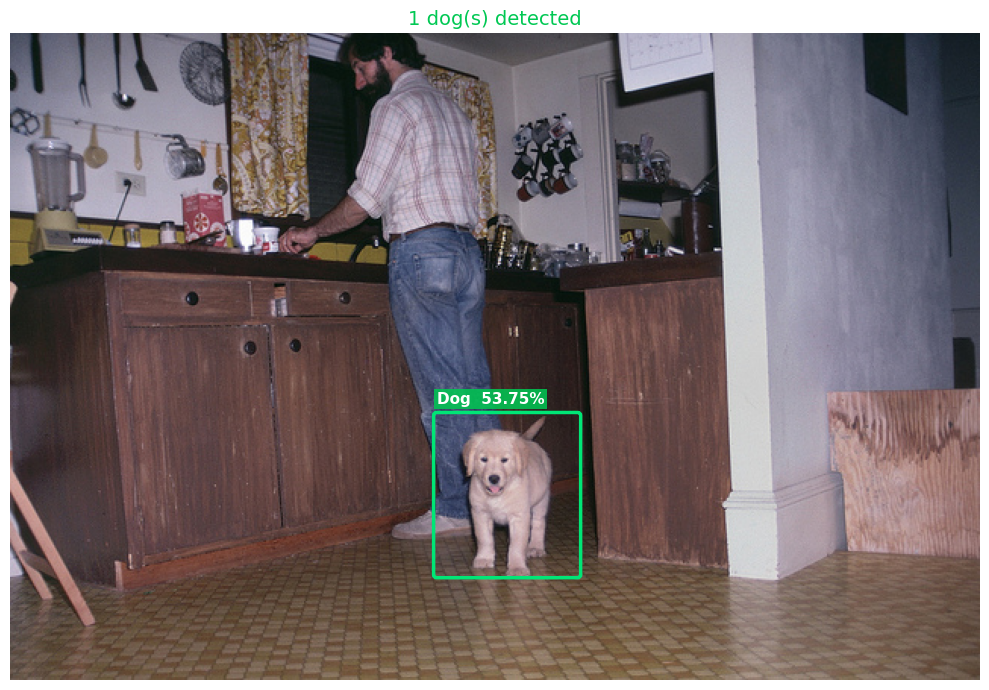


Detection Results:
  Dog 1: box=[281,252,374,357]  confidence=53.75%


In [92]:
# Pick a validation image that has dogs
test_sample = val_samples[0]
print(f'Test image: {test_sample["img_path"]}')
print(f'Ground truth boxes: {test_sample["boxes"]}')

visualise_detections(test_sample['img_path'], conf_thresh=0.35)

## STEP 17 — Test on Your Own Image

Upload any image via Kaggle's left panel → **Upload**, then update the path below.  
Works best with real outdoor scenes — dogs in parks, streets, gardens.

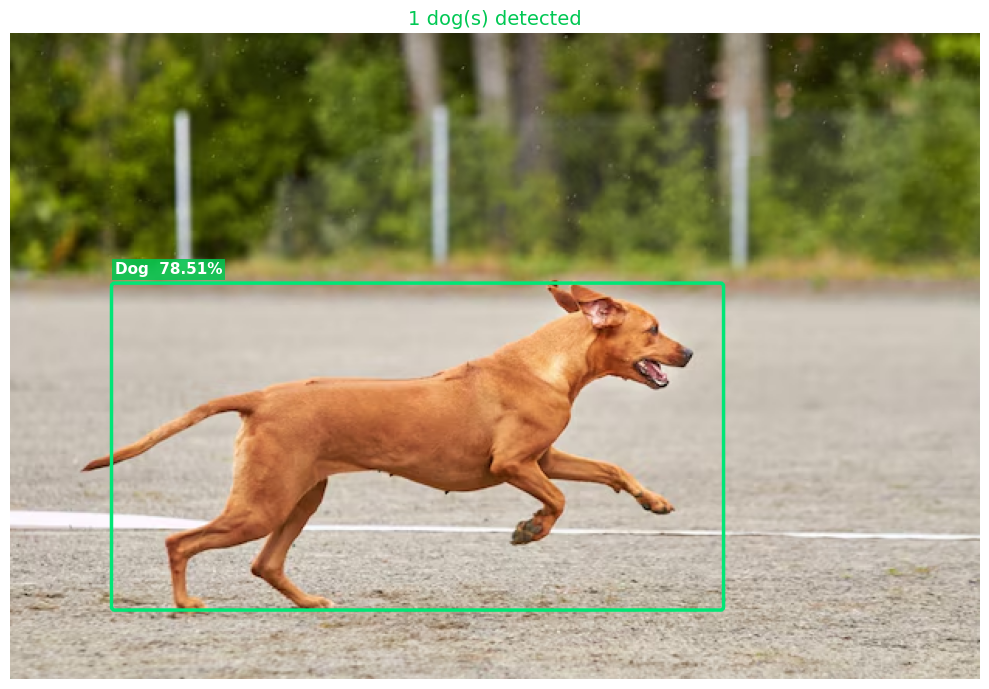


Detection Results:
  Dog 1: box=[67,163,458,370]  confidence=78.51%


In [93]:
MY_IMAGE = '/kaggle/input/datasets/pandivaishnavi2003/indianroaddogs/side-view-dog-running-road_1048944-21750566.avif'  # ← change this

if os.path.exists(MY_IMAGE):
    visualise_detections(MY_IMAGE, conf_thresh=0.4)
else:
    print(f'Image not found: {MY_IMAGE}')
    print('Falling back to a second COCO val sample...')
    visualise_detections(val_samples[5]['img_path'], conf_thresh=0.35)

## What's Next — Improving Detection Accuracy

| Improvement | What to change | Expected gain |
|---|---|---|
| Lower conf threshold | Change `conf_thresh=0.4` → `0.3` | More detections, some false positives |
| More training data | Increase `MAX_TRAIN` to full COCO dog set (~4,200 images) | +5–10% F1 |
| Unfreeze more blocks | `unfreeze_last_n_blocks(n=8)` with LR=5e-6 | Better scene understanding |
| Multi-scale patches | Add FPN-style neck between backbone and head | Better small dog detection |
| Data augmentation | Add random flip, color jitter, mosaic | Better generalisation |
| Anchor priors | Initialise bbox regression with dog-specific aspect ratios | Faster box convergence |
| Full fine-tune | Unfreeze entire backbone after Phase 2 converges | Maximum accuracy |
